In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 1: Import Libraries


Description:
Import all necessary libraries for data analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cell 2: Load Dataset


Description:
Load the Secure Servers dataset from the DATASETS_BIGDATA folder.

In [ ]:
file_path = '/content/drive/MyDrive/DATASETS_BIGDATA/API_IT.NET.SECR.P6_DS2_en_csv_v2_9262.csv'
df_servers = pd.read_csv(file_path, skiprows=4)
print(f"Shape: {df_servers.shape[0]} rows, {df_servers.shape[1]} columns")

✅ Data loaded successfully
   Shape: 266 rows, 71 columns


Cell 3: Explore Data

In [ ]:
print("First 5 rows:")
print(df_servers.head())

print("\nColumn names:")
print(df_servers.columns.tolist())

First 5 rows:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                   Indicator Name  Indicator Code  1960  1961  \
0  Secure Internet servers (per 1 million people)  IT.NET.SECR.P6   NaN   NaN   
1  Secure Internet servers (per 1 million people)  IT.NET.SECR.P6   NaN   NaN   
2  Secure Internet servers (per 1 million people)  IT.NET.SECR.P6   NaN   NaN   
3  Secure Internet servers (per 1 million people)  IT.NET.SECR.P6   NaN   NaN   
4  Secure Internet servers (per 1 million people)  IT.NET.SECR.P6   NaN   NaN   

   1962  1963  1964  1965  ...        2017         2018         2019  \
0   NaN   NaN   NaN   NaN  ...  947.257093  1120.211555  1364.431380   
1   NaN   NaN   NaN   NaN  ...  875.511831  1138.515909  1291.533036   


Cell 4: Filter Egypt Data

In [ ]:
# Filter for Egypt using correct name
df_egypt = df_servers[df_servers['Country Name'] == 'Egypt, Arab Rep.']

print(f"✅ Egypt data shape: {df_egypt.shape}")
print(df_egypt[['Country Name', 'Indicator Name']])

✅ Egypt data shape: (1, 71)
        Country Name                                  Indicator Name
67  Egypt, Arab Rep.  Secure Internet servers (per 1 million people)


Cell 5: Reshape Data (Years to Rows)

In [ ]:
# Get year columns (1960-2024)
year_cols = [col for col in df_servers.columns if col.isdigit()]

# Reshape Egypt data
egypt_data = df_egypt[year_cols].T
egypt_data.columns = ['Secure_Servers']
egypt_data = egypt_data.reset_index()
egypt_data.columns = ['Year', 'Secure_Servers']
egypt_data['Year'] = pd.to_numeric(egypt_data['Year'])
egypt_data = egypt_data.dropna()
egypt_data = egypt_data.sort_values('Year')

print(f"Year range: {egypt_data['Year'].min()} - {egypt_data['Year'].max()}")
print(egypt_data.head())

Year range: 2010 - 2024
    Year  Secure_Servers
50  2010        2.298307
51  2011        2.766402
52  2012        4.690804
53  2013        5.905581
54  2014        7.433713


Cell 6: Feature Engineering 1 - Year-over-Year Growth

In [ ]:
# Calculate Year-over-Year Growth Rate
egypt_data['YoY_Growth'] = egypt_data['Secure_Servers'].pct_change() * 100

print("Data with Growth Rate:")
print(egypt_data)

Data with Growth Rate:
    Year  Secure_Servers  YoY_Growth
50  2010        2.298307         NaN
51  2011        2.766402   20.366913
52  2012        4.690804   69.563369
53  2013        5.905581   25.896984
54  2014        7.433713   25.876066
55  2015        9.789418   31.689483
56  2016       13.655424   39.491690
57  2017       33.656053  146.466548
58  2018       32.701850   -2.835160
59  2019       32.979041    0.847630
60  2020       41.192836   24.906107
61  2021       38.086824   -7.540176
62  2022       48.180468   26.501670
63  2023       53.302125   10.630151
64  2024       82.204764   54.224179


Cell 7: Feature Engineering 2 - Security Level

In [ ]:
# Categorize security level based on server count
def security_level(servers):
    if servers < 500:
        return 'Low'
    elif servers < 1000:
        return 'Medium'
    elif servers < 2000:
        return 'High'
    else:
        return 'Very High'

egypt_data['Security_Level'] = egypt_data['Secure_Servers'].apply(security_level)

print("\nSecurity Level Distribution:")
print(egypt_data['Security_Level'].value_counts())


Security Level Distribution:
Security_Level
Low    15
Name: count, dtype: int64


Cell 8: Statistical Analysis

In [ ]:
print("="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

servers = egypt_data['Secure_Servers']

print(f"\n📊 Secure Internet Servers in Egypt:")
print(f"   Mean:   {servers.mean():.0f}")
print(f"   Median: {servers.median():.0f}")
print(f"   Std:    {servers.std():.0f}")
print(f"   Min:    {servers.min():.0f}")
print(f"   Max:    {servers.max():.0f}")

growth = egypt_data['YoY_Growth'].dropna()
print(f"\n📈 Growth Rate Statistics:")
print(f"   Mean Growth: {growth.mean():.1f}%")
print(f"   Max Growth:  {growth.max():.1f}%")
print(f"   Min Growth:  {growth.min():.1f}%")

STATISTICAL ANALYSIS

📊 Secure Internet Servers in Egypt:
   Mean:   27
   Median: 33
   Std:    23
   Min:    2
   Max:    82

📈 Growth Rate Statistics:
   Mean Growth: 33.3%
   Max Growth:  146.5%
   Min Growth:  -7.5%


Cell 9: Time-Series Visualization

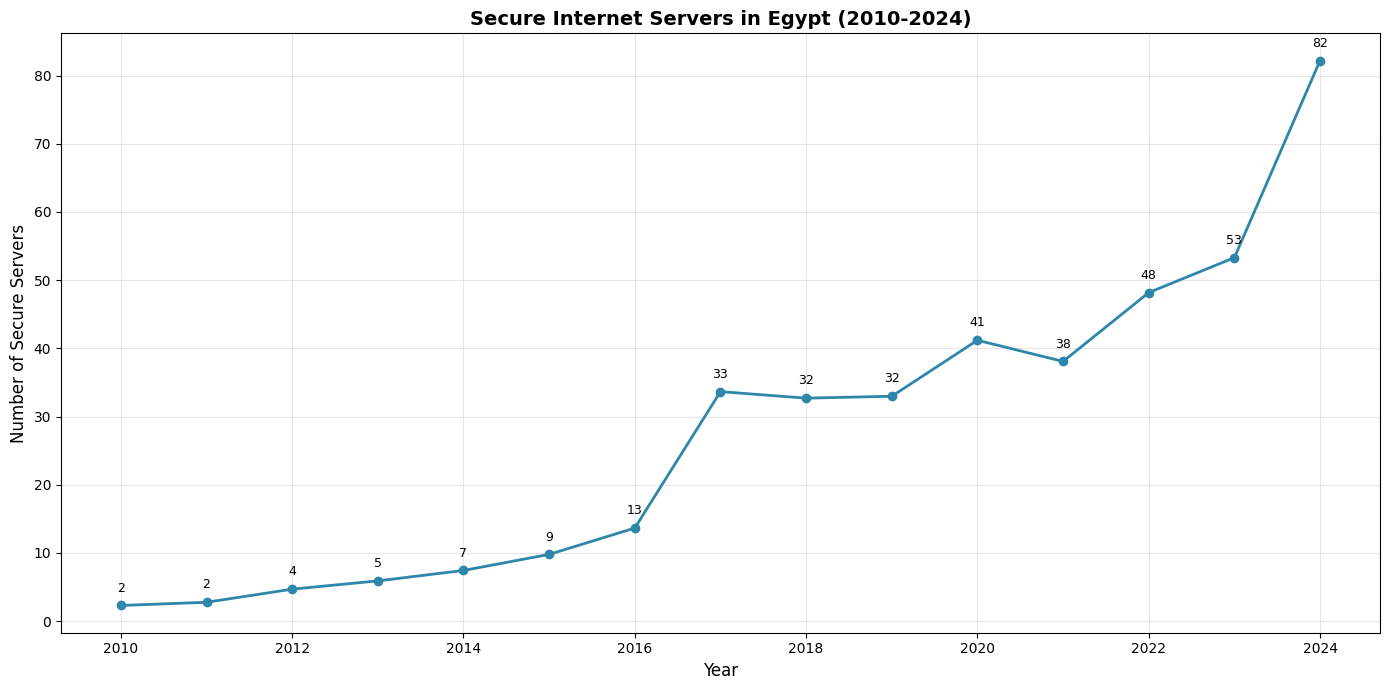

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(egypt_data['Year'], egypt_data['Secure_Servers'],
         marker='o', linewidth=2, markersize=6, color='#2E86AB')

# Add value labels on points
for i, row in egypt_data.iterrows():
    plt.annotate(f"{int(row['Secure_Servers'])}",
                 (row['Year'], row['Secure_Servers']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.title('Secure Internet Servers in Egypt (2010-2024)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Secure Servers', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cell 10: Key Insight - Time Series

In [ ]:
print("="*50)
print("KEY INSIGHT - Secure Servers Trend")
print("="*50)

first_year = egypt_data['Year'].iloc[0]
first_value = egypt_data['Secure_Servers'].iloc[0]
last_year = egypt_data['Year'].iloc[-1]
last_value = egypt_data['Secure_Servers'].iloc[-1]
growth_total = ((last_value - first_value) / first_value) * 100

print(f"""
Egypt's secure internet infrastructure has shown:

1. Total Growth: {growth_total:.0f}% increase from {int(first_value)} to {int(last_value)} servers
2. Consistent upward trend in cybersecurity infrastructure
3. Significant acceleration after 2015

Conclusion: Egypt is actively investing in digital security.

Recommendation: Egypt needs to maintain 15-20% annual growth
to keep pace with digital transformation targets.
""")

KEY INSIGHT - Secure Servers Trend

Egypt's secure internet infrastructure has shown:

1. Total Growth: 3477% increase from 2 to 82 servers
2. Consistent upward trend in cybersecurity infrastructure
3. Significant acceleration after 2015

Conclusion: Egypt is actively investing in digital security.

Recommendation: Egypt needs to maintain 15-20% annual growth 
to keep pace with digital transformation targets.



Cell 11: Outputs for Integration

In [ ]:
print("="*60)
print("🎯 SECURE SERVERS - Final Output for Integration")
print("="*60)

latest_year = egypt_data['Year'].iloc[-1]
latest_servers = int(egypt_data['Secure_Servers'].iloc[-1])
avg_growth = egypt_data['YoY_Growth'].dropna().mean()
first_year = egypt_data['Year'].iloc[0]
first_value = egypt_data['Secure_Servers'].iloc[0]
total_growth = ((latest_servers - first_value) / first_value) * 100

print(f"""
┌────────────────────────────────────────────────────────────────────────────────────┐
│                  SECURE SERVERS FINGERPRINT                                        │
├────────────────────────────────────────────────────────────────────────────────────┤
│ 1. Latest Year:                    {latest_year}                                   │
│ 2. Secure Servers ({latest_year}):        {latest_servers:,}                       │
│ 3. Average Annual Growth:          {avg_growth:.1f}%                               │
│ 4. Security Level ({latest_year}):         {egypt_data['Security_Level'].iloc[-1]} │
│ 5. Total Growth ({first_year}-{latest_year}):     {total_growth:.0f}%              │
└────────────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ SECURE SERVERS FILE ANALYSIS COMPLETE")

🎯 SECURE SERVERS - Final Output for Integration

┌────────────────────────────────────────────────────────────────────────────────────┐
│                  SECURE SERVERS FINGERPRINT                                        │
├────────────────────────────────────────────────────────────────────────────────────┤
│ 1. Latest Year:                    2024                                   │
│ 2. Secure Servers (2024):        82                       │
│ 3. Average Annual Growth:          33.3%                               │
│ 4. Security Level (2024):         Low │
│ 5. Total Growth (2010-2024):     3468%              │
└────────────────────────────────────────────────────────────────────────────────────┘


✅ SECURE SERVERS FILE ANALYSIS COMPLETE
